In [8]:
# Imports
import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader
import joblib
import random
import pickle
import numpy as np
from statistics import mean, stdev
from sklearn.metrics import roc_auc_score, precision_score, recall_score, confusion_matrix, f1_score
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.model_selection import RepeatedStratifiedKFold
import config

In [9]:
# --------------------------
# Set seeds for reproducibility
# --------------------------
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False
g = torch.Generator()
g.manual_seed(SEED)


# --------------------------
# Hyperparameters: (for my own reference)
# --------------------------
# lr (learning rate)
# batch size 32
# hidden_dim
# number_of_epochs 
# patience

# =======================
# Custom Dataset
# =======================
class MultimodalDataset(Dataset):
    def __init__(self, clin_path, mrna_path, mut_path, labels_path):
        # Load preprocessed data
        self.clinical = joblib.load(clin_path).to_numpy().astype(float)
        self.mrna = joblib.load(mrna_path).to_numpy().astype(float)
        self.mutation = joblib.load(mut_path).to_numpy().astype(float)
        self.labels = joblib.load(labels_path).to_numpy().astype(float)
        print(self.clinical.shape)
        print(self.mrna.shape)
        print(self.mutation.shape)
                
    def __len__(self):
        return len(self.labels)
    
    def __getitem__(self, idx):
        return (
            torch.tensor(self.clinical[idx], dtype=torch.float32),
            torch.tensor(self.mrna[idx], dtype=torch.float32),
            torch.tensor(self.mutation[idx], dtype=torch.float32),
            torch.tensor(self.labels[idx], dtype=torch.float32)
        )

# =======================
# Paths
# =======================
base_dir = "../preprocessed_data/no_feature_selection"

train_dataset = MultimodalDataset(
    f"{base_dir}/train/clinical.pkl",
    f"{base_dir}/train/mrna.pkl",
    f"{base_dir}/train/mutation.pkl",
    f"{base_dir}/train/labels.pkl"
)
# FIXME TESTING CHANGED VAL AND TEST
val_dataset = MultimodalDataset(
    f"{base_dir}/val/clinical.pkl",
    f"{base_dir}/val/mrna.pkl",
    f"{base_dir}/val/mutation.pkl",
    f"{base_dir}/val/labels.pkl"
)

train_loader = DataLoader(
    train_dataset, batch_size=config.BATCH_SIZE, shuffle=True, generator=g, worker_init_fn=lambda _: np.random.seed(SEED)
)
val_loader = DataLoader(
    val_dataset, batch_size=config.BATCH_SIZE, generator=g, worker_init_fn=lambda _: np.random.seed(SEED)
)

# =======================
# Simple Neural Network
# =======================
class SimpleMultimodalNet(nn.Module):
    def __init__(self, clin_dim, mrna_dim, mut_dim, hidden_dim=config.HIDDEN_DIM, dropout=config.DROPOUT):
        super().__init__()

        # Separate encoders for each modality
        self.clinical_fc = nn.Sequential(
            nn.Linear(clin_dim, hidden_dim), 
            nn.ReLU(),
            nn.Dropout(dropout)
            )
        self.mrna_fc = nn.Sequential(
            nn.Linear(mrna_dim, hidden_dim), 
            nn.ReLU(),
            nn.Dropout(dropout)
            )
        self.mut_fc = nn.Sequential(
            nn.Linear(mut_dim, hidden_dim), 
            nn.ReLU(),
            nn.Dropout(dropout)
        )
        
        # Fusion layer
        self.fusion_fc = nn.Sequential(
            nn.Linear(hidden_dim * 3, hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, 1),  # Binary output
        )
        
    def forward(self, clin, mrna, mut):
        clin_emb = self.clinical_fc(clin)
        mrna_emb = self.mrna_fc(mrna)
        mut_emb = self.mut_fc(mut)
        
        # Concatenate embeddings
        fused = torch.cat([clin_emb, mrna_emb, mut_emb], dim=1)
        output = self.fusion_fc(fused)
        return output.squeeze()




(316, 31)
(316, 17350)
(316, 17650)
(68, 31)
(68, 17350)
(68, 17650)


In [10]:
# import joblib
# import numpy as np
# import torch
# from torch.utils.data import DataLoader, Dataset

# def get_top_features_from_lasso(model_path, feature_names, top_k=None):
#     """
#     Extract top features from a trained LASSO model, sorted by absolute coefficient value (descending).
    
#     Returns:
#         selected_features (list[str]): feature names sorted by importance
#         feature_scores (dict[str, float]): {feature_name: abs(coefficient)} for selected features
#     """
#     model = joblib.load(model_path)
#     coefs = np.abs(model.coef_)
#     assert len(coefs) == len(feature_names), "Mismatch between coefficients and feature names."

#     # Sort indices by descending absolute coefficient
#     sorted_idx = np.argsort(-coefs)
#     if top_k:
#         sorted_idx = sorted_idx[:top_k]

#     # Keep only nonzero coefficients
#     selected_features = [feature_names[i] for i in sorted_idx if coefs[i] != 0]
#     feature_scores = {feature_names[i]: coefs[i] for i in sorted_idx if coefs[i] != 0}

#     # Sort by importance (redundant but ensures dict order matches)
#     selected_features = sorted(selected_features, key=lambda f: feature_scores[f], reverse=True)

#     print(f"LASSO selected {len(selected_features)} features.")
#     return selected_features, feature_scores


# def get_top_features_from_xgboost(model_path, feature_names, top_k=None):
#     """
#     Extract top features from a trained XGBoost model, sorted by feature importance (descending).
    
#     Returns:
#         selected_features (list[str]): feature names sorted by importance
#         feature_scores (dict[str, float]): {feature_name: importance} for selected features
#     """
#     model = joblib.load(model_path)
#     importances = model.feature_importances_
#     assert len(importances) == len(feature_names), "Mismatch between importances and feature names."

#     sorted_idx = np.argsort(-importances)
#     if top_k:
#         sorted_idx = sorted_idx[:top_k]

#     selected_features = [feature_names[i] for i in sorted_idx if importances[i] > 0]
#     feature_scores = {feature_names[i]: importances[i] for i in sorted_idx if importances[i] > 0}

#     # Ensure sorted order (redundant but guarantees stability)
#     selected_features = sorted(selected_features, key=lambda f: feature_scores[f], reverse=True)

#     print(f"XGBoost selected {len(selected_features)} features.")
#     return selected_features, feature_scores


# def select_features_from_models(
#     model_specs,
#     feature_names_dict,
#     data_paths,
#     combine_mode="union",
#     top_k_each=None,
#     batch_size=32,
#     shuffle=True,
#     seed=42
# ):
#     """
#     Select top features from one or more trained models and create train/val DataLoaders.

#     Args:
#         model_specs: list of dicts, each describing a model. Example:
#             [
#                 {"path": "lasso_model.joblib", "type": "lasso"},
#                 {"path": "xgb_model.joblib", "type": "xgboost"}
#             ]
#         feature_names_dict: dict with keys ['clinical', 'mrna', 'mutation'] and values = feature names list for each modality
#         data_paths: dict with keys ['train', 'val'], each mapping to dicts with paths for modalities + labels
#         combine_mode: "union" or "intersection" of selected features across models
#         top_k_each: number of top features to take from each model (None = all nonzero/positive importance)
#         batch_size: DataLoader batch size
#         shuffle: shuffle training DataLoader
#         seed: random seed
#     """
#     rng = np.random.default_rng(seed)

#     # Combine feature names across modalities
#     all_features = np.concatenate([
#         feature_names_dict["clinical"],
#         feature_names_dict["mrna"],
#         feature_names_dict["mutation"]
#     ])
#     all_selected = []

#     # ---- Loop over models and select features ----
#     for spec in model_specs:
#         model = joblib.load(spec["path"])
#         model_type = spec["type"].lower()

#         if model_type == "lasso":
#             coefs = np.abs(model.coef_)
#             ranked_idx = np.argsort(-coefs)
#             selected = all_features[ranked_idx[:top_k_each]] if top_k_each else all_features[coefs != 0]

#         elif model_type == "xgboost":
#             importances = model.feature_importances_
#             ranked_idx = np.argsort(-importances)
#             selected = all_features[ranked_idx[:top_k_each]] if top_k_each else all_features[importances > 0]

#         elif model_type == "stability":
#             # Example structure: assumes you saved a dict {"feature": score}
#             scores = model["scores"]
#             ranked = sorted(scores.items(), key=lambda x: -x[1])
#             features_sorted = np.array([f for f, _ in ranked])
#             selected = features_sorted[:top_k_each] if top_k_each else features_sorted

#         else:
#             raise ValueError(f"Unsupported model type: {model_type}")

#         print(f"{model_type.upper()} selected {len(selected)} features.")
#         all_selected.append(set(selected))

#     # ---- Combine feature sets ----
#     if combine_mode == "union":
#         combined_features = set.union(*all_selected)
#     elif combine_mode == "intersection":
#         combined_features = set.intersection(*all_selected)
#     else:
#         raise ValueError("combine_mode must be 'union' or 'intersection'.")

#     combined_features = np.array(sorted(combined_features))
#     print(f"Combined feature set: {len(combined_features)} features ({combine_mode}).")

#     # ---- Create feature masks ----
#     def get_feature_mask(feature_names, selected):
#         return np.isin(feature_names, selected)

#     clinical_mask = get_feature_mask(feature_names_dict["clinical"], combined_features)
#     mrna_mask = get_feature_mask(feature_names_dict["mrna"], combined_features)
#     mutation_mask = get_feature_mask(feature_names_dict["mutation"], combined_features)

#     # ---- Load and subset data ----
#     def load_subset(paths):
#         clin = joblib.load(paths["clinical"]).to_numpy().astype(float)[:, clinical_mask]
#         mrna = joblib.load(paths["mrna"]).to_numpy().astype(float)[:, mrna_mask]
#         mut = joblib.load(paths["mutation"]).to_numpy().astype(float)[:, mutation_mask]
#         labels = joblib.load(paths["labels"]).to_numpy().astype(float)
#         return clin, mrna, mut, labels

#     train_data = load_subset(data_paths["train"])
#     val_data = load_subset(data_paths["val"])

#     # ---- Inline Dataset ----
#     class MultimodalSubset(Dataset):
#         def __init__(self, data):
#             self.clinical, self.mrna, self.mutation, self.labels = data
#         def __len__(self):
#             return len(self.labels)
#         def __getitem__(self, idx):
#             return (
#                 torch.tensor(self.clinical[idx], dtype=torch.float32),
#                 torch.tensor(self.mrna[idx], dtype=torch.float32),
#                 torch.tensor(self.mutation[idx], dtype=torch.float32),
#                 torch.tensor(self.labels[idx], dtype=torch.float32),
#             )

#     train_loader = DataLoader(MultimodalSubset(train_data), batch_size=batch_size, shuffle=shuffle, worker_init_fn=lambda _: np.random.seed(seed))
#     val_loader = DataLoader(MultimodalSubset(val_data), batch_size=batch_size, shuffle=False, worker_init_fn=lambda _: np.random.seed(seed))

#     return train_loader, val_loader, combined_features

# base_dir = "../preprocessed_data"

# feature_names_dict = {
#     "clinical": list(joblib.load("../feature_names/clinical.pkl")),
#     "mrna": list(joblib.load("../feature_names/mrna.pkl")),
#     "mutation": list(joblib.load("../feature_names/mutation.pkl"))
# }

# data_paths = {
#     "train": {
#         "clinical": f"{base_dir}/train/clinical.pkl",
#         "mrna": f"{base_dir}/train/mrna.pkl",
#         "mutation": f"{base_dir}/train/mutation.pkl",
#         "labels": f"{base_dir}/train/labels.pkl"
#     },
#     "val": {
#         "clinical": f"{base_dir}/val/clinical.pkl",
#         "mrna": f"{base_dir}/val/mrna.pkl",
#         "mutation": f"{base_dir}/val/mutation.pkl",
#         "labels": f"{base_dir}/val/labels.pkl"
#     }
# }

# train_loader, val_loader, features_used = select_features_from_models(
#     model_specs=[
#         {"path": "../models/lasso_no_feature_selection.joblib", "type": "lasso"},
#         {"path": "../models/xgb_feature_selection.joblib", "type": "xgboost"}
#     ],
#     feature_names_dict=feature_names_dict,
#     data_paths=data_paths,
#     combine_mode="union",
#     top_k_each=300
# )


In [11]:
# =======================
# Initialize Model
# =======================
# Use one batch to get dimensions
sample_batch = next(iter(train_loader))
clin_dim = sample_batch[0].shape[1]
mrna_dim = sample_batch[1].shape[1]
mut_dim = sample_batch[2].shape[1]
model = SimpleMultimodalNet(clin_dim, mrna_dim, mut_dim)

# =======================
# Loss and Optimizer
# =======================
# Compute pos_weight
num_pos = (train_dataset.labels == 1).sum()
num_neg = (train_dataset.labels == 0).sum()
pos_weight_val = num_neg / num_pos

# Convert to tensor and move to the same device as model
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
pos_weight = torch.tensor(pos_weight_val, dtype=torch.float32, device=device)

# Initialize loss
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

# --------------------------
# Training loop with validation metrics
# --------------------------
best_auroc = 0
counter = 0

for epoch in range(config.NUM_EPOCHS):
    model.train()
    train_losses = []

    for clin, mrna, mut, labels in train_loader:
        optimizer.zero_grad()
        outputs = model(clin, mrna, mut)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        train_losses.append(loss.item())

    avg_train_loss = sum(train_losses) / len(train_losses)

    # --- Validation ---
    model.eval()
    val_losses = []
    all_labels = []
    all_preds = []

    with torch.no_grad():
        for clin, mrna, mut, labels in val_loader:
            outputs = model(clin, mrna, mut)
            val_loss = criterion(outputs, labels)
            val_losses.append(val_loss.item())
            
            all_labels.append(labels)
            all_preds.append(torch.sigmoid(outputs))

    avg_val_loss = sum(val_losses) / len(val_losses)
    all_labels = torch.cat(all_labels)
    all_preds = torch.cat(all_preds)

    # Binarize predictions at 0.5 threshold
    pred_labels = (all_preds >= 0.5).float()

    val_auroc = roc_auc_score(all_labels.numpy(), all_preds.numpy())
    val_precision = precision_score(all_labels.numpy(), pred_labels.numpy(), zero_division=0)
    val_recall = recall_score(all_labels.numpy(), pred_labels.numpy(), zero_division=0)
    val_f1 = f1_score(all_labels.numpy(), pred_labels.numpy(), zero_division=0)

    print(f"Epoch {epoch+1} - "
          f"Train Loss: {avg_train_loss:.4f}, "
          f"Val Loss: {avg_val_loss:.4f}, "
          f"AUROC: {val_auroc:.4f}, "
          f"Precision: {val_precision:.4f}, "
          f"Recall: {val_recall:.4f}, "
          f"F1: {val_f1:.4f}")

    # --- Early stopping based on AUROC ---
    if val_auroc >= best_auroc:
        best_auroc = val_auroc
        counter = 0
        # Optionally save best model
        torch.save(model.state_dict(), "best_model.pth")
    else:
        counter += 1
        if counter >= config.PATIENCE:
            print(f"Early stopping at epoch {epoch+1} with patience of {config.PATIENCE}")
            break



Epoch 1 - Train Loss: 155.5714, Val Loss: 38.5413, AUROC: 0.5000, Precision: 0.1912, Recall: 1.0000, F1: 0.3210
Epoch 2 - Train Loss: 141.8535, Val Loss: 29.1196, AUROC: 0.3818, Precision: 0.0000, Recall: 0.0000, F1: 0.0000
Epoch 3 - Train Loss: 139.5547, Val Loss: 50.0105, AUROC: 0.3832, Precision: 0.0000, Recall: 0.0000, F1: 0.0000
Epoch 4 - Train Loss: 129.1262, Val Loss: 41.1064, AUROC: 0.3944, Precision: 0.0000, Recall: 0.0000, F1: 0.0000
Epoch 5 - Train Loss: 112.3691, Val Loss: 32.2094, AUROC: 0.4035, Precision: 0.0000, Recall: 0.0000, F1: 0.0000
Epoch 6 - Train Loss: 116.9567, Val Loss: 26.1347, AUROC: 0.4266, Precision: 0.0000, Recall: 0.0000, F1: 0.0000
Epoch 7 - Train Loss: 122.8256, Val Loss: 24.0300, AUROC: 0.4727, Precision: 0.0000, Recall: 0.0000, F1: 0.0000
Epoch 8 - Train Loss: 121.9011, Val Loss: 27.6549, AUROC: 0.4811, Precision: 0.0000, Recall: 0.0000, F1: 0.0000
Epoch 9 - Train Loss: 84.4806, Val Loss: 34.1993, AUROC: 0.4783, Precision: 0.0000, Recall: 0.0000, F1: 

In [12]:
# from sklearn.metrics import (
#     roc_auc_score, precision_score, recall_score, f1_score, confusion_matrix
# )
# from statistics import mean, stdev
# from sklearn.model_selection import RepeatedStratifiedKFold

# def run_kfold_crossval(dataset, k=5, n_repeats=3):
#     rskf = RepeatedStratifiedKFold(n_splits=k, n_repeats=n_repeats, random_state=SEED)
#     labels = dataset.labels
#     indices = np.arange(len(labels))
    
#     fold_aurocs, fold_precisions, fold_recalls, fold_f1s = [], [], [], []

#     for fold, (train_idx, val_idx) in enumerate(rskf.split(indices, labels)):
#         print(f"\n===== Fold {fold+1}/{k*n_repeats} =====")
#         train_subset = torch.utils.data.Subset(dataset, train_idx)
#         val_subset = torch.utils.data.Subset(dataset, val_idx)

#         train_loader = DataLoader(train_subset, batch_size=config.BATCH_SIZE, shuffle=True)
#         val_loader = DataLoader(val_subset, batch_size=config.BATCH_SIZE)

#         # Reset seeds for reproducibility
#         seed = SEED + fold
#         random.seed(seed)
#         np.random.seed(seed)
#         torch.manual_seed(seed)
#         torch.cuda.manual_seed_all(seed)
#         torch.backends.cudnn.deterministic = True
#         torch.backends.cudnn.benchmark = False

#         # Rebuild model
#         model = SimpleMultimodalNet(clin_dim, mrna_dim, mut_dim).to(device)
#         optimizer = torch.optim.Adam(model.parameters(), lr=1e-4, weight_decay=1e-5)
#         criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

#         best_val_auroc = 0
#         best_model_state = None
#         counter = 0

#         # --- Training ---
#         for epoch in range(config.NUM_EPOCHS):
#             model.train()
#             for clin, mrna, mut, labels_batch in train_loader:
#                 clin, mrna, mut, labels_batch = (
#                     clin.to(device),
#                     mrna.to(device),
#                     mut.to(device),
#                     labels_batch.to(device),
#                 )
#                 optimizer.zero_grad()
#                 outputs = model(clin, mrna, mut)
#                 loss = criterion(outputs, labels_batch)
#                 loss.backward()
#                 optimizer.step()

#             # --- Validation ---
#             model.eval()
#             all_labels, all_preds = [], []
#             with torch.no_grad():
#                 for clin, mrna, mut, labels_batch in val_loader:
#                     clin, mrna, mut, labels_batch = (
#                         clin.to(device),
#                         mrna.to(device),
#                         mut.to(device),
#                         labels_batch.to(device),
#                     )
#                     outputs = model(clin, mrna, mut)
#                     all_labels.append(labels_batch.cpu())
#                     all_preds.append(torch.sigmoid(outputs).cpu())

#             all_labels = torch.cat(all_labels)
#             all_preds = torch.cat(all_preds)
#             val_auroc = roc_auc_score(all_labels.numpy(), all_preds.numpy())

#             if val_auroc > best_val_auroc:
#                 best_val_auroc = val_auroc
#                 best_model_state = model.state_dict()
#                 counter = 0
#             else:
#                 counter += 1
#                 if counter >= config.PATIENCE:
#                     break

#         # --- Evaluate best model on validation ---
#         model.load_state_dict(best_model_state)
#         model.eval()
#         all_labels, all_preds = [], []
#         with torch.no_grad():
#             for clin, mrna, mut, labels_batch in val_loader:
#                 clin, mrna, mut, labels_batch = (
#                     clin.to(device),
#                     mrna.to(device),
#                     mut.to(device),
#                     labels_batch.to(device),
#                 )
#                 outputs = model(clin, mrna, mut)
#                 all_labels.append(labels_batch.cpu())
#                 all_preds.append(torch.sigmoid(outputs).cpu())

#         all_labels = torch.cat(all_labels)
#         all_preds = torch.cat(all_preds)
#         pred_labels = (all_preds >= 0.5).float()

#         auroc = roc_auc_score(all_labels, all_preds)
#         precision = precision_score(all_labels, pred_labels, zero_division=0)
#         recall = recall_score(all_labels, pred_labels, zero_division=0)
#         f1 = f1_score(all_labels, pred_labels, zero_division=0)
#         tn, fp, fn, tp = confusion_matrix(all_labels, pred_labels).ravel()

#         print(f"Fold {fold+1} AUROC: {auroc:.4f}, Precision: {precision:.4f}, Recall: {recall:.4f}, F1: {f1:.4f}")
#         print(f"Confusion Matrix: TP={tp}, FP={fp}, TN={tn}, FN={fn}")

#         fold_aurocs.append(auroc)
#         fold_precisions.append(precision)
#         fold_recalls.append(recall)
#         fold_f1s.append(f1)

#     # --- Summary ---
#     print("\n==========================")
#     print(" K-Fold Summary ")
#     print("==========================")
#     print(f"Mean AUROC    : {mean(fold_aurocs):.4f} ± {stdev(fold_aurocs):.4f}")
#     print(f"Mean Precision: {mean(fold_precisions):.4f} ± {stdev(fold_precisions):.4f}")
#     print(f"Mean Recall   : {mean(fold_recalls):.4f} ± {stdev(fold_recalls):.4f}")
#     print(f"Mean F1-score : {mean(fold_f1s):.4f} ± {stdev(fold_f1s):.4f}")
#     print(f"All AUROCs    : {[round(a, 4) for a in fold_aurocs]}")

# run_kfold_crossval(train_dataset, k=5, n_repeats=3)



===== Fold 1/15 =====
Selected optimal threshold=0.00 (f1=0.4118)
Fold 1 AUROC: 0.6346, Precision: 0.3182, Recall: 0.5833, F1: 0.4118
→ External Validation AUROC: 0.8056, Precision: 0.4167, Recall: 0.7692, F1: 0.5405

===== Fold 2/15 =====
Selected optimal threshold=0.88 (f1=0.4762)
Fold 2 AUROC: 0.6438, Precision: 0.5556, Recall: 0.4167, F1: 0.4762
→ External Validation AUROC: 0.7483, Precision: 0.3077, Recall: 0.3077, F1: 0.3077

===== Fold 3/15 =====
Selected optimal threshold=0.01 (f1=0.3902)
Fold 3 AUROC: 0.6569, Precision: 0.2759, Recall: 0.6667, F1: 0.3902
→ External Validation AUROC: 0.8210, Precision: 0.3636, Recall: 0.6154, F1: 0.4571

===== Fold 4/15 =====
Selected optimal threshold=0.00 (f1=0.3871)
Fold 4 AUROC: 0.6783, Precision: 0.3000, Recall: 0.5455, F1: 0.3871
→ External Validation AUROC: 0.8000, Precision: 0.3810, Recall: 0.6154, F1: 0.4706

===== Fold 5/15 =====
Selected optimal threshold=0.79 (f1=0.3667)
Fold 5 AUROC: 0.6722, Precision: 0.2245, Recall: 1.0000, F1: 

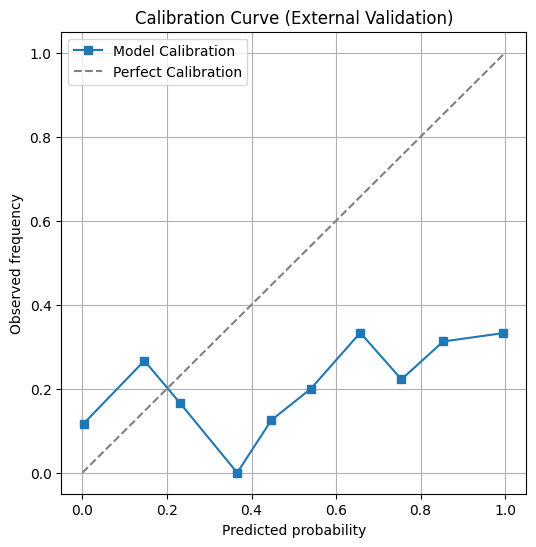

In [13]:
from sklearn.calibration import calibration_curve
import matplotlib.pyplot as plt

def run_kfold_crossval_with_external_val(train_dataset, external_val_dataset, k=5, n_repeats=3, optimize_metric='f1'):
    rskf = RepeatedStratifiedKFold(n_splits=k, n_repeats=n_repeats, random_state=SEED)
    labels = train_dataset.labels
    indices = np.arange(len(labels))
    
    fold_aurocs, fold_precisions, fold_recalls, fold_f1s, fold_thresholds = [], [], [], [], []
    external_aurocs, external_precisions, external_recalls, external_f1s = [], [], [], []
    all_ext_preds, all_ext_labels = [], []  # store across folds for calibration visualization

    ext_val_loader = DataLoader(external_val_dataset, batch_size=config.BATCH_SIZE)

    for fold, (train_idx, val_idx) in enumerate(rskf.split(indices, labels)):
        print(f"\n===== Fold {fold+1}/{k*n_repeats} =====")

        train_subset = torch.utils.data.Subset(train_dataset, train_idx)
        val_subset = torch.utils.data.Subset(train_dataset, val_idx)

        train_loader = DataLoader(train_subset, batch_size=config.BATCH_SIZE, shuffle=True)
        val_loader = DataLoader(val_subset, batch_size=config.BATCH_SIZE)

        # Reset seeds for reproducibility
        seed = SEED + fold
        random.seed(seed)
        np.random.seed(seed)
        torch.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False

        model = SimpleMultimodalNet(clin_dim, mrna_dim, mut_dim).to(device)
        optimizer = torch.optim.Adam(model.parameters(), lr=1e-4, weight_decay=1e-5)
        criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

        best_val_auroc = 0
        best_model_state = None
        counter = 0

        # === Training with early stopping ===
        for epoch in range(config.NUM_EPOCHS):
            model.train()
            for clin, mrna, mut, labels_batch in train_loader:
                clin, mrna, mut, labels_batch = (
                    clin.to(device), mrna.to(device), mut.to(device), labels_batch.to(device)
                )
                optimizer.zero_grad()
                outputs = model(clin, mrna, mut)
                loss = criterion(outputs, labels_batch)
                loss.backward()
                optimizer.step()

            # Validation
            model.eval()
            all_labels, all_preds = [], []
            with torch.no_grad():
                for clin, mrna, mut, labels_batch in val_loader:
                    clin, mrna, mut, labels_batch = (
                        clin.to(device), mrna.to(device), mut.to(device), labels_batch.to(device)
                    )
                    outputs = model(clin, mrna, mut)
                    all_labels.append(labels_batch.cpu())
                    all_preds.append(torch.sigmoid(outputs).cpu())

            all_labels = torch.cat(all_labels)
            all_preds = torch.cat(all_preds)
            val_auroc = roc_auc_score(all_labels.numpy(), all_preds.numpy())

            if val_auroc > best_val_auroc:
                best_val_auroc = val_auroc
                best_model_state = model.state_dict()
                counter = 0
            else:
                counter += 1
                if counter >= config.PATIENCE:
                    break

        # === Evaluate on validation fold ===
        model.load_state_dict(best_model_state)
        model.eval()
        all_labels, all_preds = [], []
        with torch.no_grad():
            for clin, mrna, mut, labels_batch in val_loader:
                clin, mrna, mut, labels_batch = (
                    clin.to(device), mrna.to(device), mut.to(device), labels_batch.to(device)
                )
                outputs = model(clin, mrna, mut)
                all_labels.append(labels_batch.cpu())
                all_preds.append(torch.sigmoid(outputs).cpu())

        all_labels = torch.cat(all_labels).numpy()
        all_preds = torch.cat(all_preds).numpy()

        # === Choose threshold ===
        best_thresh, best_metric = 0.5, -1
        for t in np.linspace(0.001, 0.9, 200):
            pred_labels = (all_preds >= t).astype(float)
            if optimize_metric == 'f1':
                metric_val = f1_score(all_labels, pred_labels, zero_division=0)
            elif optimize_metric == 'youden':
                tn, fp, fn, tp = confusion_matrix(all_labels, pred_labels).ravel()
                sensitivity = tp / (tp + fn + 1e-9)
                specificity = tn / (tn + fp + 1e-9)
                metric_val = sensitivity + specificity - 1
            if metric_val > best_metric:
                best_metric, best_thresh = metric_val, t

        threshold = best_thresh
        fold_thresholds.append(threshold)
        print(f"Selected optimal threshold={threshold:.2f} ({optimize_metric}={best_metric:.4f})")

        pred_labels = (all_preds >= threshold).astype(float)
        auroc = roc_auc_score(all_labels, all_preds)
        precision = precision_score(all_labels, pred_labels, zero_division=0)
        recall = recall_score(all_labels, pred_labels, zero_division=0)
        f1 = f1_score(all_labels, pred_labels, zero_division=0)
        fold_aurocs.append(auroc)
        fold_precisions.append(precision)
        fold_recalls.append(recall)
        fold_f1s.append(f1)

        print(f"Fold {fold+1} AUROC: {auroc:.4f}, Precision: {precision:.4f}, Recall: {recall:.4f}, F1: {f1:.4f}")

        # === External validation ===
        all_labels, all_preds = [], []
        with torch.no_grad():
            for clin, mrna, mut, labels_batch in ext_val_loader:
                clin, mrna, mut, labels_batch = (
                    clin.to(device), mrna.to(device), mut.to(device), labels_batch.to(device)
                )
                outputs = model(clin, mrna, mut)
                all_labels.append(labels_batch.cpu())
                all_preds.append(torch.sigmoid(outputs).cpu())

        all_labels = torch.cat(all_labels).numpy()
        all_preds = torch.cat(all_preds).numpy()
        pred_labels = (all_preds >= threshold).astype(float)

        all_ext_labels.extend(all_labels)
        all_ext_preds.extend(all_preds)

        ext_auroc = roc_auc_score(all_labels, all_preds)
        ext_precision = precision_score(all_labels, pred_labels, zero_division=0)
        ext_recall = recall_score(all_labels, pred_labels, zero_division=0)
        ext_f1 = f1_score(all_labels, pred_labels, zero_division=0)
        external_aurocs.append(ext_auroc)
        external_precisions.append(ext_precision)
        external_recalls.append(ext_recall)
        external_f1s.append(ext_f1)

        print(f"→ External Validation AUROC: {ext_auroc:.4f}, Precision: {ext_precision:.4f}, Recall: {ext_recall:.4f}, F1: {ext_f1:.4f}")

    # === Summary ===
    print("\n==========================")
    print(" K-Fold Summary (Internal) ")
    print("==========================")
    print(f"Mean AUROC    : {mean(fold_aurocs):.4f} ± {stdev(fold_aurocs):.4f}")
    print(f"Mean Precision: {mean(fold_precisions):.4f} ± {stdev(fold_precisions):.4f}")
    print(f"Mean Recall   : {mean(fold_recalls):.4f} ± {stdev(fold_recalls):.4f}")
    print(f"Mean F1-score : {mean(fold_f1s):.4f} ± {stdev(fold_f1s):.4f}")

    print("\n==========================")
    print(" External Validation Summary ")
    print("==========================")
    print(f"Mean AUROC    : {mean(external_aurocs):.4f} ± {stdev(external_aurocs):.4f}")
    print(f"Mean Precision: {mean(external_precisions):.4f} ± {stdev(external_precisions):.4f}")
    print(f"Mean Recall   : {mean(external_recalls):.4f} ± {stdev(external_recalls):.4f}")
    print(f"Mean F1-score : {mean(external_f1s):.4f} ± {stdev(external_f1s):.4f}")

    # === Calibration plot ===
    prob_true, prob_pred = calibration_curve(all_ext_labels, all_ext_preds, n_bins=10)
    plt.figure(figsize=(6, 6))
    plt.plot(prob_pred, prob_true, "s-", label="Model Calibration")
    plt.plot([0, 1], [0, 1], "--", color="gray", label="Perfect Calibration")
    plt.xlabel("Predicted probability")
    plt.ylabel("Observed frequency")
    plt.title("Calibration Curve (External Validation)")
    plt.legend()
    plt.grid(True)
    plt.show()

run_kfold_crossval_with_external_val(train_dataset, val_dataset,  k=5, n_repeats=3, optimize_metric='f1')


In [14]:
# from sklearn.metrics import (
#     roc_auc_score, precision_score, recall_score, f1_score, confusion_matrix
# )
# from statistics import mean, stdev
# from sklearn.model_selection import RepeatedStratifiedKFold
# import numpy as np
# import torch, random, torch.nn as nn
# from torch.utils.data import DataLoader
# from sklearn.calibration import calibration_curve

# def run_kfold_crossval_with_external_val(train_dataset, external_val_dataset, k=5, n_repeats=3, optimize_metric='f1'):
#     rskf = RepeatedStratifiedKFold(n_splits=k, n_repeats=n_repeats, random_state=SEED)
#     labels = train_dataset.labels
#     indices = np.arange(len(labels))
    
#     fold_aurocs, fold_precisions, fold_recalls, fold_f1s, fold_thresholds = [], [], [], [], []
#     external_aurocs, external_precisions, external_recalls, external_f1s = [], [], [], []

#     ext_val_loader = DataLoader(external_val_dataset, batch_size=config.BATCH_SIZE)

#     for fold, (train_idx, val_idx) in enumerate(rskf.split(indices, labels)):
#         print(f"\n===== Fold {fold+1}/{k*n_repeats} =====")

#         train_subset = torch.utils.data.Subset(train_dataset, train_idx)
#         val_subset = torch.utils.data.Subset(train_dataset, val_idx)

#         train_loader = DataLoader(train_subset, batch_size=config.BATCH_SIZE, shuffle=True)
#         val_loader = DataLoader(val_subset, batch_size=config.BATCH_SIZE)

#         # Reset seeds for reproducibility
#         seed = SEED + fold
#         random.seed(seed)
#         np.random.seed(seed)
#         torch.manual_seed(seed)
#         torch.cuda.manual_seed_all(seed)
#         torch.backends.cudnn.deterministic = True
#         torch.backends.cudnn.benchmark = False

#         # Build model
#         model = SimpleMultimodalNet(clin_dim, mrna_dim, mut_dim).to(device)
#         optimizer = torch.optim.Adam(model.parameters(), lr=1e-4, weight_decay=1e-5)
#         criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

#         best_val_auroc = 0
#         best_model_state = None
#         counter = 0

#         # --- Training with early stopping ---
#         for epoch in range(config.NUM_EPOCHS):
#             model.train()
#             for clin, mrna, mut, labels_batch in train_loader:
#                 clin, mrna, mut, labels_batch = (
#                     clin.to(device),
#                     mrna.to(device),
#                     mut.to(device),
#                     labels_batch.to(device),
#                 )
#                 optimizer.zero_grad()
#                 outputs = model(clin, mrna, mut)
#                 loss = criterion(outputs, labels_batch)
#                 loss.backward()
#                 optimizer.step()

#             # --- Validation ---
#             model.eval()
#             all_labels, all_preds = [], []
#             with torch.no_grad():
#                 for clin, mrna, mut, labels_batch in val_loader:
#                     clin, mrna, mut, labels_batch = (
#                         clin.to(device),
#                         mrna.to(device),
#                         mut.to(device),
#                         labels_batch.to(device),
#                     )
#                     outputs = model(clin, mrna, mut)
#                     all_labels.append(labels_batch.cpu())
#                     all_preds.append(torch.sigmoid(outputs).cpu())

#             all_labels = torch.cat(all_labels)
#             all_preds = torch.cat(all_preds)
#             val_auroc = roc_auc_score(all_labels.numpy(), all_preds.numpy())

#             if val_auroc > best_val_auroc:
#                 best_val_auroc = val_auroc
#                 best_model_state = model.state_dict()
#                 counter = 0
#             else:
#                 counter += 1
#                 if counter >= config.PATIENCE:
#                     break

#         # --- Evaluate best model on its validation fold ---
#         model.load_state_dict(best_model_state)
#         model.eval()
#         all_labels, all_preds = [], []
#         with torch.no_grad():
#             for clin, mrna, mut, labels_batch in val_loader:
#                 clin, mrna, mut, labels_batch = (
#                     clin.to(device),
#                     mrna.to(device),
#                     mut.to(device),
#                     labels_batch.to(device),
#                 )
#                 outputs = model(clin, mrna, mut)
#                 all_labels.append(labels_batch.cpu())
#                 all_preds.append(torch.sigmoid(outputs).cpu())

#         all_labels = torch.cat(all_labels).numpy()
#         all_preds = torch.cat(all_preds).numpy()

#         # --- Choose threshold ---
#         best_thresh, best_metric = 0.5, -1
#         for t in np.linspace(0.001, 0.9, 200):
#             pred_labels = (all_preds >= t).astype(float)
#             if optimize_metric == 'f1':
#                 metric_val = f1_score(all_labels, pred_labels, zero_division=0)
#             elif optimize_metric == 'youden':
#                 tn, fp, fn, tp = confusion_matrix(all_labels, pred_labels).ravel()
#                 sensitivity = tp / (tp + fn + 1e-9)
#                 specificity = tn / (tn + fp + 1e-9)
#                 metric_val = sensitivity + specificity - 1
#             if metric_val > best_metric:
#                 best_metric, best_thresh = metric_val, t

#         threshold = best_thresh
#         fold_thresholds.append(threshold)
#         print(f"Selected optimal threshold={threshold:.2f} ({optimize_metric}={best_metric:.4f})")

#         # --- Evaluate on *fold validation* set ---
#         pred_labels = (all_preds >= threshold).astype(float)
#         auroc = roc_auc_score(all_labels, all_preds)
#         precision = precision_score(all_labels, pred_labels, zero_division=0)
#         recall = recall_score(all_labels, pred_labels, zero_division=0)
#         f1 = f1_score(all_labels, pred_labels, zero_division=0)
#         fold_aurocs.append(auroc)
#         fold_precisions.append(precision)
#         fold_recalls.append(recall)
#         fold_f1s.append(f1)

#         print(f"Fold {fold+1} AUROC: {auroc:.4f}, Precision: {precision:.4f}, Recall: {recall:.4f}, F1: {f1:.4f}")

#         # --- Evaluate best model on *external validation set* ---
#         all_labels, all_preds = [], []
#         with torch.no_grad():
#             for clin, mrna, mut, labels_batch in ext_val_loader:
#                 clin, mrna, mut, labels_batch = (
#                     clin.to(device),
#                     mrna.to(device),
#                     mut.to(device),
#                     labels_batch.to(device),
#                 )
#                 outputs = model(clin, mrna, mut)
#                 all_labels.append(labels_batch.cpu())
#                 all_preds.append(torch.sigmoid(outputs).cpu())

#         all_labels = torch.cat(all_labels).numpy()
#         all_preds = torch.cat(all_preds).numpy()
#         pred_labels = (all_preds >= threshold).astype(float)

#         ext_auroc = roc_auc_score(all_labels, all_preds)
#         ext_precision = precision_score(all_labels, pred_labels, zero_division=0)
#         ext_recall = recall_score(all_labels, pred_labels, zero_division=0)
#         ext_f1 = f1_score(all_labels, pred_labels, zero_division=0)
#         external_aurocs.append(ext_auroc)
#         external_precisions.append(ext_precision)
#         external_recalls.append(ext_recall)
#         external_f1s.append(ext_f1)

#         print(f"→ External Validation AUROC: {ext_auroc:.4f}, Precision: {ext_precision:.4f}, Recall: {ext_recall:.4f}, F1: {ext_f1:.4f}")

#     # --- Summary ---
#     print("\n==========================")
#     print(" K-Fold Summary (Internal) ")
#     print("==========================")
#     print(f"Mean AUROC    : {mean(fold_aurocs):.4f} ± {stdev(fold_aurocs):.4f}")
#     print(f"Mean Precision: {mean(fold_precisions):.4f} ± {stdev(fold_precisions):.4f}")
#     print(f"Mean Recall   : {mean(fold_recalls):.4f} ± {stdev(fold_recalls):.4f}")
#     print(f"Mean F1-score : {mean(fold_f1s):.4f} ± {stdev(fold_f1s):.4f}")

#     print("\n==========================")
#     print(" External Validation Summary ")
#     print("==========================")
#     print(f"Mean AUROC    : {mean(external_aurocs):.4f} ± {stdev(external_aurocs):.4f}")
#     print(f"Mean Precision: {mean(external_precisions):.4f} ± {stdev(external_precisions):.4f}")
#     print(f"Mean Recall   : {mean(external_recalls):.4f} ± {stdev(external_recalls):.4f}")
#     print(f"Mean F1-score : {mean(external_f1s):.4f} ± {stdev(external_f1s):.4f}")


# test_dataset = MultimodalDataset(
#     f"{base_dir}/test/clinical.pkl",
#     f"{base_dir}/test/mrna.pkl",
#     f"{base_dir}/test/mutation.pkl",
#     f"{base_dir}/test/labels.pkl"
# )

# test_loader = DataLoader(test_dataset, batch_size=32)

# run_kfold_crossval_with_external_val(train_dataset, test_dataset,  k=5, n_repeats=3, optimize_metric='f1')


===== Fold 1/5 =====
Selected optimal threshold=0.00 (f1=0.4118)
Fold 1 AUROC: 0.6346, AUPRC: 0.3173, Precision: 0.3182, Recall: 0.5833, F1: 0.4118
→ External Validation AUROC: 0.8056, AUPRC: 0.5648, Precision: 0.4167, Recall: 0.7692, F1: 0.5405

===== Fold 2/5 =====
Selected optimal threshold=0.88 (f1=0.4762)
Fold 2 AUROC: 0.6438, AUPRC: 0.3047, Precision: 0.5556, Recall: 0.4167, F1: 0.4762
→ External Validation AUROC: 0.7483, AUPRC: 0.3088, Precision: 0.3077, Recall: 0.3077, F1: 0.3077

===== Fold 3/5 =====
Selected optimal threshold=0.01 (f1=0.3902)
Fold 3 AUROC: 0.6569, AUPRC: 0.3867, Precision: 0.2759, Recall: 0.6667, F1: 0.3902
→ External Validation AUROC: 0.8210, AUPRC: 0.5576, Precision: 0.3636, Recall: 0.6154, F1: 0.4571

===== Fold 4/5 =====
Selected optimal threshold=0.00 (f1=0.3871)
Fold 4 AUROC: 0.6783, AUPRC: 0.2555, Precision: 0.3000, Recall: 0.5455, F1: 0.3871
→ External Validation AUROC: 0.8000, AUPRC: 0.3843, Precision: 0.3810, Recall: 0.6154, F1: 0.4706

===== Fold 

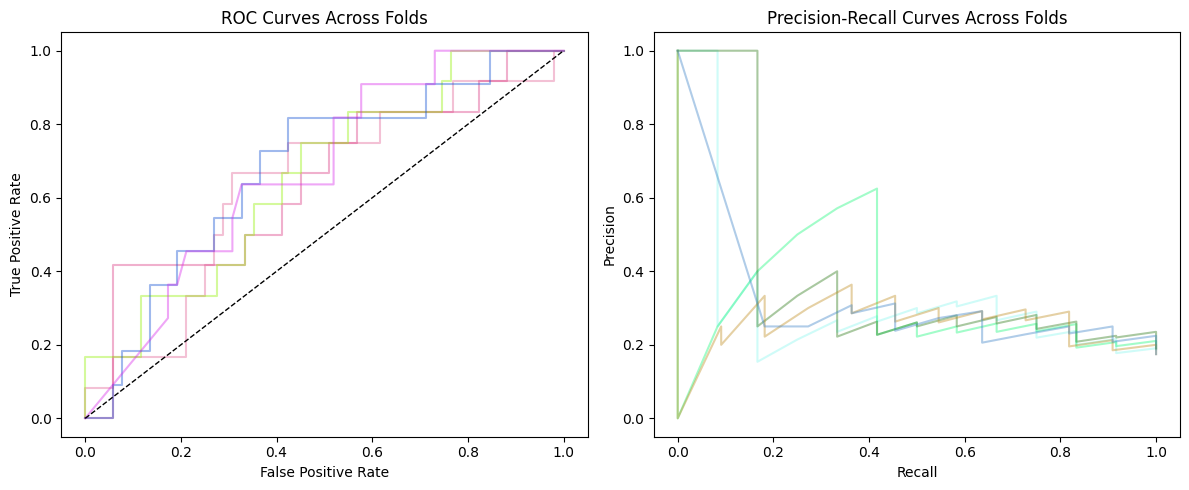

{'internal': {'AUROC': [0.6346153846153847,
   0.6437908496732027,
   0.6568627450980392,
   0.6783216783216783,
   0.6722027972027972],
  'AUPRC': [0.31729457512150183,
   0.30467160803467663,
   0.38666183525371844,
   0.25545696792019856,
   0.3208063915330913],
  'F1': [0.4117647058823529,
   0.47619047619047616,
   0.3902439024390244,
   0.3870967741935484,
   0.36666666666666664]},
 'external': {'AUROC': [0.8055944055944056,
   0.7482517482517483,
   0.8209790209790211,
   0.8,
   0.7482517482517482],
  'AUPRC': [0.564794746698642,
   0.3087767154882553,
   0.5575523512976823,
   0.3842959187351552,
   0.40496410316453535],
  'F1': [0.5405405405405406,
   0.3076923076923077,
   0.45714285714285713,
   0.47058823529411764,
   0.37681159420289856]}}

In [15]:
from sklearn.metrics import (
    roc_auc_score, precision_score, recall_score, f1_score,
    confusion_matrix, roc_curve, precision_recall_curve, auc
)
from statistics import mean, stdev
from sklearn.model_selection import RepeatedStratifiedKFold
import numpy as np
import matplotlib.pyplot as plt
import torch, random, torch.nn as nn
from torch.utils.data import DataLoader

def run_kfold_crossval_with_external_val(train_dataset, external_val_dataset, k=5, n_repeats=3, optimize_metric='f1'):
    rskf = RepeatedStratifiedKFold(n_splits=k, n_repeats=n_repeats, random_state=SEED)
    labels = train_dataset.labels
    indices = np.arange(len(labels))

    # Store metrics
    fold_aurocs, fold_auprcs, fold_precisions, fold_recalls, fold_f1s, fold_thresholds = [], [], [], [], [], []
    external_aurocs, external_auprcs, external_precisions, external_recalls, external_f1s = [], [], [], [], []

    # ROC & PR curves (for plotting)
    roc_curves, pr_curves = [], []
    ext_roc_curves, ext_pr_curves = [], []

    ext_val_loader = DataLoader(external_val_dataset, batch_size=config.BATCH_SIZE)

    for fold, (train_idx, val_idx) in enumerate(rskf.split(indices, labels)):
        print(f"\n===== Fold {fold+1}/{k*n_repeats} =====")

        train_subset = torch.utils.data.Subset(train_dataset, train_idx)
        val_subset = torch.utils.data.Subset(train_dataset, val_idx)

        train_loader = DataLoader(train_subset, batch_size=config.BATCH_SIZE, shuffle=True)
        val_loader = DataLoader(val_subset, batch_size=config.BATCH_SIZE)

        # Reset seeds for reproducibility
        seed = SEED + fold
        random.seed(seed)
        np.random.seed(seed)
        torch.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False

        # Build model
        model = SimpleMultimodalNet(clin_dim, mrna_dim, mut_dim).to(device)
        optimizer = torch.optim.Adam(model.parameters(), lr=1e-4, weight_decay=1e-5)
        criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

        best_val_auroc = 0
        best_model_state = None
        counter = 0

        # --- Training with early stopping ---
        for epoch in range(config.NUM_EPOCHS):
            model.train()
            for clin, mrna, mut, labels_batch in train_loader:
                clin, mrna, mut, labels_batch = (
                    clin.to(device),
                    mrna.to(device),
                    mut.to(device),
                    labels_batch.to(device),
                )
                optimizer.zero_grad()
                outputs = model(clin, mrna, mut)
                loss = criterion(outputs, labels_batch)
                loss.backward()
                optimizer.step()

            # --- Validation ---
            model.eval()
            all_labels, all_preds = [], []
            with torch.no_grad():
                for clin, mrna, mut, labels_batch in val_loader:
                    clin, mrna, mut, labels_batch = (
                        clin.to(device),
                        mrna.to(device),
                        mut.to(device),
                        labels_batch.to(device),
                    )
                    outputs = model(clin, mrna, mut)
                    all_labels.append(labels_batch.cpu())
                    all_preds.append(torch.sigmoid(outputs).cpu())

            all_labels = torch.cat(all_labels)
            all_preds = torch.cat(all_preds)
            val_auroc = roc_auc_score(all_labels.numpy(), all_preds.numpy())

            if val_auroc > best_val_auroc:
                best_val_auroc = val_auroc
                best_model_state = model.state_dict()
                counter = 0
            else:
                counter += 1
                if counter >= config.PATIENCE:
                    break

        # --- Evaluate best model ---
        model.load_state_dict(best_model_state)
        model.eval()
        all_labels, all_preds = [], []
        with torch.no_grad():
            for clin, mrna, mut, labels_batch in val_loader:
                clin, mrna, mut, labels_batch = (
                    clin.to(device),
                    mrna.to(device),
                    mut.to(device),
                    labels_batch.to(device),
                )
                outputs = model(clin, mrna, mut)
                all_labels.append(labels_batch.cpu())
                all_preds.append(torch.sigmoid(outputs).cpu())

        all_labels = torch.cat(all_labels).numpy()
        all_preds = torch.cat(all_preds).numpy()

        # --- ROC & PR curves ---
        fpr, tpr, _ = roc_curve(all_labels, all_preds)
        precision_curve, recall_curve, _ = precision_recall_curve(all_labels, all_preds)
        roc_curves.append((fpr, tpr))
        pr_curves.append((recall_curve, precision_curve))

        auroc = roc_auc_score(all_labels, all_preds)
        auprc = auc(recall_curve, precision_curve)

        # --- Choose threshold ---
        best_thresh, best_metric = 0.5, -1
        for t in np.linspace(0.001, 0.9, 200):
            pred_labels = (all_preds >= t).astype(float)
            if optimize_metric == 'f1':
                metric_val = f1_score(all_labels, pred_labels, zero_division=0)
            elif optimize_metric == 'youden':
                tn, fp, fn, tp = confusion_matrix(all_labels, pred_labels).ravel()
                sensitivity = tp / (tp + fn + 1e-9)
                specificity = tn / (tn + fp + 1e-9)
                metric_val = sensitivity + specificity - 1
            if metric_val > best_metric:
                best_metric, best_thresh = metric_val, t

        threshold = best_thresh
        fold_thresholds.append(threshold)
        pred_labels = (all_preds >= threshold).astype(float)
        precision = precision_score(all_labels, pred_labels, zero_division=0)
        recall = recall_score(all_labels, pred_labels, zero_division=0)
        f1 = f1_score(all_labels, pred_labels, zero_division=0)

        fold_aurocs.append(auroc)
        fold_auprcs.append(auprc)
        fold_precisions.append(precision)
        fold_recalls.append(recall)
        fold_f1s.append(f1)

        print(f"Selected optimal threshold={threshold:.2f} ({optimize_metric}={best_metric:.4f})")
        print(f"Fold {fold+1} AUROC: {auroc:.4f}, AUPRC: {auprc:.4f}, Precision: {precision:.4f}, Recall: {recall:.4f}, F1: {f1:.4f}")

        # --- External Validation ---
        all_labels, all_preds = [], []
        with torch.no_grad():
            for clin, mrna, mut, labels_batch in ext_val_loader:
                clin, mrna, mut, labels_batch = (
                    clin.to(device),
                    mrna.to(device),
                    mut.to(device),
                    labels_batch.to(device),
                )
                outputs = model(clin, mrna, mut)
                all_labels.append(labels_batch.cpu())
                all_preds.append(torch.sigmoid(outputs).cpu())

        all_labels = torch.cat(all_labels).numpy()
        all_preds = torch.cat(all_preds).numpy()

        fpr, tpr, _ = roc_curve(all_labels, all_preds)
        precision_curve, recall_curve, _ = precision_recall_curve(all_labels, all_preds)
        ext_roc_curves.append((fpr, tpr))
        ext_pr_curves.append((recall_curve, precision_curve))

        ext_auroc = roc_auc_score(all_labels, all_preds)
        ext_auprc = auc(recall_curve, precision_curve)
        pred_labels = (all_preds >= threshold).astype(float)
        ext_precision = precision_score(all_labels, pred_labels, zero_division=0)
        ext_recall = recall_score(all_labels, pred_labels, zero_division=0)
        ext_f1 = f1_score(all_labels, pred_labels, zero_division=0)

        external_aurocs.append(ext_auroc)
        external_auprcs.append(ext_auprc)
        external_precisions.append(ext_precision)
        external_recalls.append(ext_recall)
        external_f1s.append(ext_f1)

        print(f"→ External Validation AUROC: {ext_auroc:.4f}, AUPRC: {ext_auprc:.4f}, Precision: {ext_precision:.4f}, Recall: {ext_recall:.4f}, F1: {ext_f1:.4f}")

    # --- Summary ---
    print("\n==========================")
    print(" K-Fold Summary (Internal) ")
    print("==========================")
    print(f"Mean AUROC : {mean(fold_aurocs):.4f} ± {stdev(fold_aurocs):.4f}")
    print(f"Mean AUPRC : {mean(fold_auprcs):.4f} ± {stdev(fold_auprcs):.4f}")
    print(f"Mean F1    : {mean(fold_f1s):.4f} ± {stdev(fold_f1s):.4f}")

    print("\n==========================")
    print(" External Validation Summary ")
    print("==========================")
    print(f"Mean AUROC : {mean(external_aurocs):.4f} ± {stdev(external_aurocs):.4f}")
    print(f"Mean AUPRC : {mean(external_auprcs):.4f} ± {stdev(external_auprcs):.4f}")
    print(f"Mean F1    : {mean(external_f1s):.4f} ± {stdev(external_f1s):.4f}")

    # --- Visualization ---
    plt.figure(figsize=(12, 5))

    # ROC Curves
    plt.subplot(1, 2, 1)
    for fpr, tpr in roc_curves:
        random_color = (random.random(), random.random(), random.random())
        plt.plot(fpr, tpr, color=random_color, alpha=0.4)
    plt.plot([0, 1], [0, 1], 'k--', lw=1)
    plt.title('ROC Curves Across Folds')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')

    # PR Curves
    plt.subplot(1, 2, 2)
    for recall_curve, precision_curve in pr_curves:
        random_color = (random.random(), random.random(), random.random())
        plt.plot(recall_curve, precision_curve, color=random_color, alpha=0.4)
    plt.title('Precision-Recall Curves Across Folds')
    plt.xlabel('Recall')
    plt.ylabel('Precision')

    plt.tight_layout()
    plt.show()

    return {
        "internal": {"AUROC": fold_aurocs, "AUPRC": fold_auprcs, "F1": fold_f1s},
        "external": {"AUROC": external_aurocs, "AUPRC": external_auprcs, "F1": external_f1s},
    }

run_kfold_crossval_with_external_val(train_dataset, val_dataset, k=5, n_repeats=1, optimize_metric='f1')

In [ ]:
def run_multiple_seeds_with_test(train_loader, val_loader, test_loader, num_runs=5):
    val_aurocs = []
    test_aurocs = []
    
    for i in range(num_runs):
        seed = 42 + i
        print(f"\n==========================")
        print(f" Run {i+1}/{num_runs} with SEED={seed}")
        print(f"==========================")
        
        # --- Set seeds for reproducibility ---
        random.seed(seed)
        np.random.seed(seed)
        torch.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False
        
        # --- Reinitialize model, loss, optimizer ---
        model = SimpleMultimodalNet(clin_dim, mrna_dim, mut_dim).to(device)
        optimizer = torch.optim.Adam(model.parameters(), lr=config.LEARNING_RATE, weight_decay=1e-5)
        criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
        
        best_auroc = 0
        best_model_state = None
        counter = 0
        
        # --- Training loop ---
        for epoch in range(config.NUM_EPOCHS):
            model.train()
            for clin, mrna, mut, labels in train_loader:
                clin, mrna, mut, labels = clin.to(device), mrna.to(device), mut.to(device), labels.to(device)
                optimizer.zero_grad()
                outputs = model(clin, mrna, mut)
                loss = criterion(outputs, labels)
                loss.backward()
                optimizer.step()
            
            # --- Validation phase ---
            model.eval()
            all_labels, all_preds = [], []
            with torch.no_grad():
                for clin, mrna, mut, labels in val_loader:
                    clin, mrna, mut, labels = clin.to(device), mrna.to(device), mut.to(device), labels.to(device)
                    outputs = model(clin, mrna, mut)
                    all_labels.append(labels.cpu())
                    all_preds.append(torch.sigmoid(outputs).cpu())
            
            all_labels = torch.cat(all_labels)
            all_preds = torch.cat(all_preds)
            val_auroc = roc_auc_score(all_labels.numpy(), all_preds.numpy())
            
            if val_auroc > best_auroc:
                best_auroc = val_auroc
                best_model_state = model.state_dict()
                counter = 0
            else:
                counter += 1
                if counter >= config.PATIENCE:
                    break
        
        print(f"Best Validation AUROC for SEED {seed}: {best_auroc:.4f}")
        val_aurocs.append(best_auroc)
        
        # --- Evaluate best model on test set ---
        model.load_state_dict(best_model_state)
        model.eval()
        all_labels, all_preds = [], []
        with torch.no_grad():
            for clin, mrna, mut, labels in test_loader:
                clin, mrna, mut, labels = clin.to(device), mrna.to(device), mut.to(device), labels.to(device)
                outputs = model(clin, mrna, mut)
                all_labels.append(labels.cpu())
                all_preds.append(torch.sigmoid(outputs).cpu())
        
        all_labels = torch.cat(all_labels)
        all_preds = torch.cat(all_preds)
        test_auroc = roc_auc_score(all_labels.numpy(), all_preds.numpy())
        
        print(f"Test AUROC for SEED {seed}: {test_auroc:.4f}")
        test_aurocs.append(test_auroc)
    
    # --- Summary ---
    print("\n==========================")
    print(" Summary across runs ")
    print("==========================")
    print(f"Validation AUROC: Mean={mean(val_aurocs):.4f}, Std={stdev(val_aurocs):.4f}")
    print(f"Test AUROC      : Mean={mean(test_aurocs):.4f}, Std={stdev(test_aurocs):.4f}")
    print(f"All Validation Runs: {[round(a, 4) for a in val_aurocs]}")
    print(f"All Test Runs       : {[round(a, 4) for a in test_aurocs]}")


test_dataset = MultimodalDataset(
    f"{base_dir}/test/clinical.pkl",
    f"{base_dir}/test/mrna.pkl",
    f"{base_dir}/test/mutation.pkl",
    f"{base_dir}/test/labels.pkl"
)

test_loader = DataLoader(test_dataset, batch_size=32)

run_multiple_seeds_with_test(train_loader, val_loader, test_loader, num_runs=5)

(68, 31)
(68, 17350)
(68, 17650)

 Run 1/5 with SEED=42
Best Validation AUROC for SEED 42: 0.8182
Test AUROC for SEED 42: 0.7098

 Run 2/5 with SEED=43
Best Validation AUROC for SEED 43: 0.8084
Test AUROC for SEED 43: 0.6875

 Run 3/5 with SEED=44


With dropout = 0:
Validation AUROC: Mean=0.7799, Std=0.0259
Test AUROC      : Mean=0.7363, Std=0.0236
All Validation Runs: [0.8126, 0.7972, 0.772, 0.772, 0.7455]
All Test Runs       : [0.7083, 0.7664, 0.7411, 0.7173, 0.7485]

In [ ]:
model.load_state_dict(torch.load("best_model.pth"))
model.eval()
all_labels = []
all_probs = []

with torch.no_grad():
    for clin, mrna, mut, labels in val_loader:
        outputs = model(clin, mrna, mut)
        probs = torch.sigmoid(outputs)
        
        all_labels.append(labels)
        all_probs.append(probs)

# Concatenate batches
all_labels = torch.cat(all_labels).cpu().numpy()
all_probs = torch.cat(all_probs).cpu().numpy()

# --- Find optimal threshold based on F1 score ---
thresholds = np.linspace(0, 1, 101)  # 0.00, 0.01, ..., 1.00
f1_scores = []

for t in thresholds:
    preds = (all_probs >= t).astype(float)
    f1 = f1_score(all_labels, preds)
    f1_scores.append(f1)

best_idx = np.argmax(f1_scores)
best_threshold = thresholds[best_idx]
print(f"Optimal threshold for F1: {best_threshold:.2f}, F1 score: {f1_scores[best_idx]:.4f}")

# Use optimal threshold for predictions
preds = (all_probs >= best_threshold).astype(float)

# Metrics
val_loss = criterion(torch.tensor(all_probs), torch.tensor(all_labels)).item()
precision = precision_score(all_labels, preds)
recall = recall_score(all_labels, preds)
auroc = roc_auc_score(all_labels, all_probs)
cm = confusion_matrix(all_labels, preds)

# Unpack confusion matrix
tn, fp, fn, tp = cm.ravel()

print(f"Validation Loss: {val_loss:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"AUROC: {auroc:.4f}")
print("Confusion Matrix:")
print(f"True Negatives: {tn}")
print(f"False Positives: {fp}")
print(f"False Negatives: {fn}")
print(f"True Positives: {tp}")

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc, precision_recall_curve, average_precision_score

def plot_metrics(y_true, y_scores):
    y_true = y_true.numpy()
    y_scores = y_scores.numpy()
    
    # ---------- AUROC ----------
    fpr, tpr, _ = roc_curve(y_true, y_scores)
    roc_auc = auc(fpr, tpr)
    
    plt.figure(figsize=(12,5))
    
    plt.subplot(1, 2, 1)
    plt.plot(fpr, tpr, color='blue', label=f'AUROC = {roc_auc:.3f}')
    plt.plot([0,1], [0,1], color='gray', linestyle='--')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('ROC Curve')
    plt.legend(loc='lower right')
    
    # ----------  AUPRC ----------
    precision, recall, _ = precision_recall_curve(y_true, y_scores)
    ap_score = average_precision_score(y_true, y_scores)
    
    plt.subplot(1, 2, 2)
    plt.plot(recall, precision, color='green', label=f'AUPRC = {ap_score:.3f}')
    plt.xlabel('Recall')
    plt.ylabel('Precision')
    plt.title('Precision-Recall Curve')
    plt.legend(loc='lower left')
    
    plt.tight_layout()
    plt.show()

model.eval()
all_labels = []
all_outputs = []
with torch.no_grad():
    for clin, mrna, mut, labels in val_loader:
        outputs = model(clin, mrna, mut)
        all_outputs.append(torch.sigmoid(outputs))
        all_labels.append(labels)

all_labels = torch.cat(all_labels)
all_outputs = torch.cat(all_outputs)

plot_metrics(all_labels, all_outputs)

In [ ]:
test_dataset = MultimodalDataset(
    f"{base_dir}/test/clinical.pkl",
    f"{base_dir}/test/mrna.pkl",
    f"{base_dir}/test/mutation.pkl",
    f"{base_dir}/test/labels.pkl"
)

test_loader = DataLoader(test_dataset, batch_size=32)



model.load_state_dict(torch.load("best_model.pth"))
model.eval()
all_labels = []
all_probs = []

with torch.no_grad():
    for clin, mrna, mut, labels in test_loader:
        outputs = model(clin, mrna, mut)
        probs = torch.sigmoid(outputs)
        
        all_labels.append(labels)
        all_probs.append(probs)

# Concatenate batches
all_labels = torch.cat(all_labels).cpu().numpy()
all_probs = torch.cat(all_probs).cpu().numpy()

# --- Find optimal threshold based on F1 score ---
thresholds = np.linspace(0, 1, 101)  # 0.00, 0.01, ..., 1.00
f1_scores = []

for t in thresholds:
    preds = (all_probs >= t).astype(float)
    f1 = f1_score(all_labels, preds)
    f1_scores.append(f1)

best_idx = np.argmax(f1_scores)
best_threshold = thresholds[best_idx]
print(f"Optimal threshold for F1: {best_threshold:.2f}, F1 score: {f1_scores[best_idx]:.4f}")

# Use optimal threshold for predictions
preds = (all_probs >= best_threshold).astype(float)

# Metrics
test_loss = criterion(torch.tensor(all_probs), torch.tensor(all_labels)).item()
precision = precision_score(all_labels, preds)
recall = recall_score(all_labels, preds)
auroc = roc_auc_score(all_labels, all_probs)
cm = confusion_matrix(all_labels, preds)

# Unpack confusion matrix
tn, fp, fn, tp = cm.ravel()

print(f"Test Loss: {test_loss:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"AUROC: {auroc:.4f}")
print("Confusion Matrix:")
print(f"True Negatives: {tn}")
print(f"False Positives: {fp}")
print(f"False Negatives: {fn}")
print(f"True Positives: {tp}")

In [ ]:
model.eval()
all_labels = []
all_outputs = []
with torch.no_grad():
    for clin, mrna, mut, labels in test_loader:
        outputs = model(clin, mrna, mut)
        all_outputs.append(torch.sigmoid(outputs))
        all_labels.append(labels)

all_labels = torch.cat(all_labels)
all_outputs = torch.cat(all_outputs)

plot_metrics(all_labels, all_outputs)